# 01 - Backpropagation and Function Approximation

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## Opening the Black Box

In `cv_primer/03-neural-networks.ipynb`, we trained a real neural network with `sklearn`'s `MLPClassifier`, but glossed over how: *"Most of these (`solver`, `batch_size`, `max_iter`) are implementation details you don't need to worry about yet."* This notebook is where we worry about them - we'll build a small network from scratch, with no `sklearn`, and write the training loop ourselves.

We'll also deliberately point it somewhere other than images. `cv_primer` motivated neural networks with CIFAR-10 image classification; this notebook uses plain tabular numbers instead - the same shape of data as a scouted team's stats - because that's what a value or policy network will actually take as input in the Reinforcement Learning primer that follows this one.

## A Tiny Network, By Hand

Recall from `linear_algebra_primer/02-matrices-and-transformations.ipynb`: a layer's output is $f(Wx + b)$ - a matrix-vector product, plus a bias, through an activation function. Our network here has one input, one hidden layer of 2 neurons (ReLU activation), and one output neuron (no activation - a **Regression Head**, since we're predicting a continuous number):

$$ z_1 = W_1 x + b_1, \qquad a_1 = \text{ReLU}(z_1) $$
$$ z_2 = W_2 a_1 + b_2, \qquad \hat{y} = z_2 $$

where $W_1$ is a $2\times1$ matrix (2 hidden neurons, 1 input each), $W_2$ is a $1\times2$ matrix (1 output neuron, 2 hidden inputs), and $b_1, b_2$ are bias vectors.

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# small random initial weights - this is exactly what MLPClassifier does internally
# before you ever call .fit()
W1 = np.random.randn(2, 1) * 0.5   # hidden layer: 2 neurons, 1 input each
b1 = np.zeros((2, 1))
W2 = np.random.randn(1, 2) * 0.5   # output layer: 1 neuron, 2 hidden inputs
b2 = np.zeros((1, 1))

def forward_pass(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    z2 = W2 @ a1 + b2
    y_hat = z2
    return z1, a1, y_hat

# sanity check: run one input through the untrained network
x_sample = np.array([[2.0]])
z1, a1, y_hat = forward_pass(x_sample, W1, b1, W2, b2)
print(f"Untrained network output for x=2.0: {y_hat.item():.3f} (should be close to random)")

Untrained network output for x=2.0: 0.049 (should be close to random)


## Approximating a Nonlinear Function

`cv_primer/03` motivated neural networks with: *"Neural Networks... are very useful because they help us model nonlinear relationships between inputs and outputs."* Let's actually test that here, on a target function a single linear layer (like the `ml_primer` regression notebooks) could never fit: $y = x^2$.

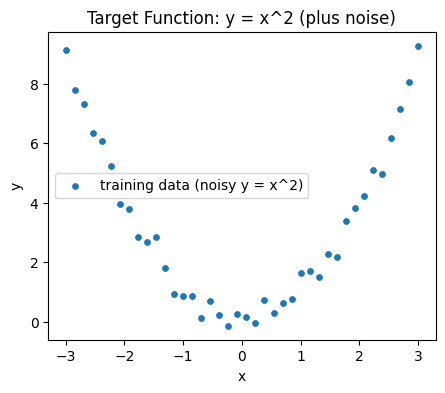

In [3]:
x_train = np.linspace(-3, 3, 40)
y_train = x_train**2 + np.random.normal(0, 0.3, size=len(x_train))   # noisy y = x^2

plt.figure(figsize=(5, 4))
plt.scatter(x_train, y_train, s=15, label='training data (noisy y = x^2)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Target Function: y = x^2 (plus noise)')
plt.show()

## The Chain Rule and Backpropagation

To train the network, we need the gradient of the loss with respect to *every* weight - including $W_1$, which is buried two layers back from the loss. That gradient has to pass through everything in between, via the **Chain Rule**:

$$ \frac{\partial \text{Loss}}{\partial W_1} = \frac{\partial \text{Loss}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1} $$

That's the entire idea behind **Backpropagation**: start at the loss, compute how much the output layer contributed, then keep working backward, one layer at a time, multiplying in each layer's own local derivative as you go. It's the exact same chain rule you'd use in a calculus class - there's no additional trick hiding inside it, just a lot of bookkeeping once there are many layers and many weights.

In [4]:
def backward_pass(x, y, z1, a1, y_hat, W2):
    n = x.shape[1]   # number of examples in this batch

    # dLoss/dy_hat, for Loss = mean squared error
    d_loss_d_yhat = 2 * (y_hat - y) / n

    # output layer gradients (Loss -> y_hat -> W2, b2)
    d_W2 = d_loss_d_yhat @ a1.T
    d_b2 = np.sum(d_loss_d_yhat, axis=1, keepdims=True)

    # backpropagate through the output layer to the hidden activations
    d_a1 = W2.T @ d_loss_d_yhat
    d_z1 = d_a1 * relu_derivative(z1)   # chain rule through the ReLU activation

    # hidden layer gradients (continuing the chain rule back to W1, b1)
    d_W1 = d_z1 @ x.T
    d_b1 = np.sum(d_z1, axis=1, keepdims=True)

    return d_W1, d_b1, d_W2, d_b2

In [5]:
# training loop: forward pass, compute loss, backward pass, gradient descent update, repeat
x_batch = x_train.reshape(1, -1)
y_batch = y_train.reshape(1, -1)

learning_rate = 0.01
n_epochs = 2000
loss_history = []

for epoch in range(n_epochs):
    z1, a1, y_hat = forward_pass(x_batch, W1, b1, W2, b2)
    loss = np.mean((y_hat - y_batch) ** 2)
    loss_history.append(loss)

    d_W1, d_b1, d_W2, d_b2 = backward_pass(x_batch, y_batch, z1, a1, y_hat, W2)

    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2

print(f"Loss at epoch 0:    {loss_history[0]:.3f}")
print(f"Loss at epoch {n_epochs-1}: {loss_history[-1]:.3f}")

Loss at epoch 0:    17.716
Loss at epoch 1999: 4.981


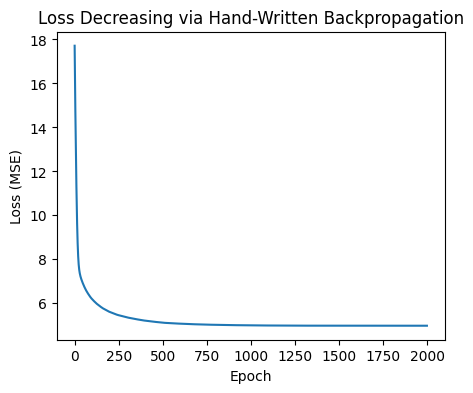

In [6]:
plt.figure(figsize=(5, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Decreasing via Hand-Written Backpropagation')
plt.show()

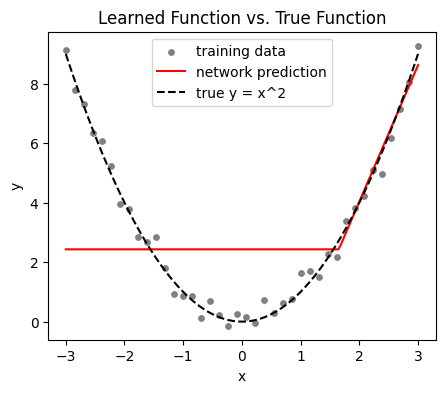

In [7]:
# visualize the learned function against the true one
x_test = np.linspace(-3, 3, 200).reshape(1, -1)
_, _, y_pred = forward_pass(x_test, W1, b1, W2, b2)

plt.figure(figsize=(5, 4))
plt.scatter(x_train, y_train, s=15, color='gray', label='training data')
plt.plot(x_test.flatten(), y_pred.flatten(), color='red', label='network prediction')
plt.plot(x_test.flatten(), (x_test.flatten())**2, color='black', linestyle='--', label='true y = x^2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Learned Function vs. True Function')
plt.show()

With only 2 hidden neurons, our from-scratch network gets a rough approximation of the curve, not a perfect one - a hint that hidden-layer size matters, which the exercise below asks you to test directly. But notice what just happened: every step of that training loop (forward pass, loss, backward pass, weight update, repeat) is exactly what `MLPClassifier.fit()` was doing inside `cv_primer/03`, just with `sklearn` choosing a better optimizer than plain gradient descent (that's what `solver='adam'` was) and doing the chain-rule bookkeeping across far more layers and neurons than our 2-neuron example needs.

## Try It Yourself

1. Increase the hidden layer from 2 neurons to 8 (you'll need to resize `W1` to `(8, 1)`, `b1` to `(8, 1)`, and `W2` to `(1, 8)`). Retrain and compare the final loss and the learned-vs-true plot to the 2-neuron version above.
2. Swap the target function from `y_train = x_train**2 + noise` to something harder, e.g. `y_train = np.sin(x_train) * 3 + noise`, and retrain your 8-neuron network on it. Does it still converge? If the fit looks poor, which do you think is the more likely cause: too few neurons, too few epochs, or too small a learning rate - and how would you check which one it actually is?

In [8]:
# TODO: 1. resize W1, b1, W2 for 8 hidden neurons, retrain, and compare to the 2-neuron result

# TODO: 2. swap in a harder target function (e.g. sin(x) * 3) and retrain


## Resources

- [3Blue1Brown: Backpropagation Calculus](https://www.3blue1brown.com/lessons/backpropagation-calculus) - the chain-rule mechanics this notebook implements, explained visually (video).
- [CS231n: Backpropagation Notes](https://cs231n.github.io/optimization-2/) - a more formal, worked-example treatment of the same derivation (instructional).
- [scikit-learn: `MLPClassifier` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) - the black box this notebook opened, for comparison (reference).